In [1]:
import numpy as np
import pandas as pd
import scipy.spatial
from scipy.sparse import lil_matrix, csgraph
import geopandas as gpd
import matplotlib.pyplot as plt

import datetime
from tx_fast_hydrology.muskingum import Muskingum, ModelCollection
from tx_fast_hydrology.simulation import AsyncSimulation
from tx_fast_hydrology.io import ModelDecoder, ModelEncoder

# Read data

In [2]:
nhf_path = '/home/akagi/Documents/Data/txswift/nhf_1.1.3.gpkg'
nhd_path = '/home/akagi/Documents/Data/GIS/NHD_H_Texas_State_GDB/NHD_H_Texas_State_GDB.gdb'
nhf_subbasins = gpd.read_file(nhf_path, layer='divides')
nhd_flowlines = gpd.read_file(nhd_path, layer=18)

/home/akagi/.local/lib/python3.11/site-packages/pyogrio/raw.py:196: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiLineString' is converted to 'MultiLineString Z'
  return ogr_read(


# Clip to study area

In [3]:
xmin, ymin, xmax, ymax = nhf_subbasins.to_crs(nhd_flowlines.crs).total_bounds
nhd_flowlines = nhd_flowlines.cx[xmin:xmax, ymin:ymax]
nhd_flowlines = nhd_flowlines.reset_index(drop=True)
geom_array = nhd_flowlines.geometry

In [4]:
# Ensure multilinestrings are actually linestrings
assert max(geom_array.apply(lambda x: len(x.geoms)).values) == 1

# Create and query spatial index of start and end points of flowlines

In [5]:
coords = geom_array.apply(lambda x: x.geoms[0]).apply(lambda y: y.coords.xy)
x = coords.str[0]
y = coords.str[1]
x0, x1 = x.str[0], x.str[-1]
y0, y1 = y.str[0], y.str[-1]
p0 = np.column_stack([x0.values, y0.values])
p1 = np.column_stack([x1.values, y1.values])
xy = np.column_stack([np.concatenate(x.values), np.concatenate(y.values)])

p0_indices = np.asarray([0] + x.str.len().cumsum().values.tolist()[:-1])
p1_indices = (x.str.len().cumsum() - 1).values
radius = 4
threshold = 0.

tree = scipy.spatial.KDTree(xy)
arr_lens = x.apply(lambda x: len(x))
point_indices = np.repeat(arr_lens.index.values, arr_lens.values)
start_dists, start_indices = tree.query(p0, k=radius)
end_dists, end_indices = tree.query(p1, k=radius)

# Connect upstream ends based on proximity

In [6]:
starts = point_indices[start_indices]
upstream = {}
upstream_points = {}
upstream_dists = {}
upstream_failed = []

for i in range(p0.shape[0]):
    upstream[i] = []
    upstream_points[i] = []
    upstream_dists[i] = []
    for j in range(radius):
        if start_dists[i,j] <= threshold:
            if starts[i,j] != i:
                upstream[i].append(starts[i,j])
                upstream_points[i].append(start_indices[i,j])
                upstream_dists[i].append(start_dists[i,j])
    if not upstream[i]:
        upstream_failed.append(i)

In [7]:
print(f'{len(upstream_failed)} upstream connections unmatched')

53153 upstream connections unmatched


# Connect downstream ends based on proximity

In [8]:
ends = point_indices[end_indices]
downstream = {}
downstream_points = {}
downstream_dists = {}
downstream_failed = []

for i in range(p1.shape[0]):
    downstream[i] = []
    downstream_points[i] = []
    downstream_dists[i] = []
    for j in range(radius):
        if end_dists[i,j] <= threshold:
            if ends[i, j] != i:
                downstream[i].append(ends[i,j])
                downstream_points[i].append(end_indices[i,j])
                downstream_dists[i].append(end_dists[i,j])
    if not downstream[i]:
        downstream_failed.append(i)

In [9]:
print(f'{len(downstream_failed)} downstream connections unmatched')

1193 downstream connections unmatched


# Check connectivity

In [10]:
n = nhd_flowlines.shape[0]
adj = lil_matrix((n, n), dtype=int)
nodes = np.arange(n)
for i in nodes:
    j = upstream[i]
    k = downstream[i]
    if j:
        for jj in j:
            adj[i, jj] = 1
            adj[jj, i] = 1
    if k:
        for kk in k:
            adj[kk, i] = 1
            adj[i, kk] = 1

In [11]:
num_components, labels = csgraph.connected_components(adj,
                                                      directed=True,
                                                      connection='weak')

In [12]:
num_components

1240

# Create reach-to-reach mapping

In [13]:
nhd_flowlines['id'] = nhd_flowlines.index
nhd_flowlines['to_id'] = -9999
nhd_flowlines['watershed_label'] = labels
nhd_flowlines['watershed_name'] = ''

In [14]:
outlets = {
    'trinity' : '93945390',
    'brazos' : '99484203',
    'tehuacana' : '99484129',
    'north_bosque' : '97226535',
    'leon' : '102477322',
    'cowhouse' : '68287377',
    'pompey' : '74077411',
    'kickapoo' : '114048101',
    'south_sulphur' : '93414060',
    'north_sulphur' : '93407674',
    'white_oak' : '109624662',
    'lake_fork' : '127099278',
    'sabine' : '93702098',
    'choctaw' : '93541603',
    'caney' : '93541897',
    'mill' : '93541961',
    'little_wichita' : '93283294',
    'east_little_wichita' : '93284156',
    'west_belknap' : '148292707',
    'blanket' : '74077257'
}

for watershed_name, outlet in outlets.items():
    print(watershed_name)
    outlet_index = nhd_flowlines[nhd_flowlines['permanent_identifier'] == outlet].index.item()
    dist, pred = csgraph.shortest_path(adj, return_predecessors=True, indices=outlet_index)
    for i, j in zip(nodes, pred):
        if j != -9999:
            nhd_flowlines.loc[i, 'to_id'] = nhd_flowlines.loc[j, 'id']
            nhd_flowlines.loc[i, 'watershed_name'] = watershed_name
    nhd_flowlines.loc[outlet_index, 'to_id'] = nhd_flowlines.loc[outlet_index, 'id']
    nhd_flowlines.loc[outlet_index, 'watershed_name'] = watershed_name

trinity
brazos
tehuacana
north_bosque
leon
cowhouse
pompey
kickapoo
south_sulphur
north_sulphur
white_oak
lake_fork
sabine
choctaw
caney
mill
little_wichita
east_little_wichita
west_belknap
blanket


In [15]:
print(f"{100 * (nhd_flowlines['to_id'] == -9999).sum() / len(nhd_flowlines):.2f}% reaches not included")

8.68% reaches not included


In [16]:
# Ensure that each watershed drains to a common point
assert (nhd_flowlines.groupby('watershed_name')['watershed_label'].unique().drop('').str.len() == 1).all()

In [17]:
for watershed_name, outlet in outlets.items():
    basin = nhd_flowlines[nhd_flowlines['watershed_name'] == watershed_name]
    assert basin['to_id'].isin(basin['id']).all()

In [18]:
basins = {}

for watershed_name, outlet in outlets.items():
    print(watershed_name)
    basin = nhd_flowlines[nhd_flowlines['watershed_name'] == watershed_name].copy()
    id_mapping = pd.Series(np.arange(len(basin)), index=basin['id'])
    basin.index = id_mapping.values
    basin['id'] = id_mapping.loc[basin['id']].values
    basin['to_id'] = id_mapping.loc[basin['to_id']].values
    basins[watershed_name] = basin

trinity
brazos
tehuacana
north_bosque
leon
cowhouse
pompey
kickapoo
south_sulphur
north_sulphur
white_oak
lake_fork
sabine
choctaw
caney
mill
little_wichita
east_little_wichita
west_belknap
blanket


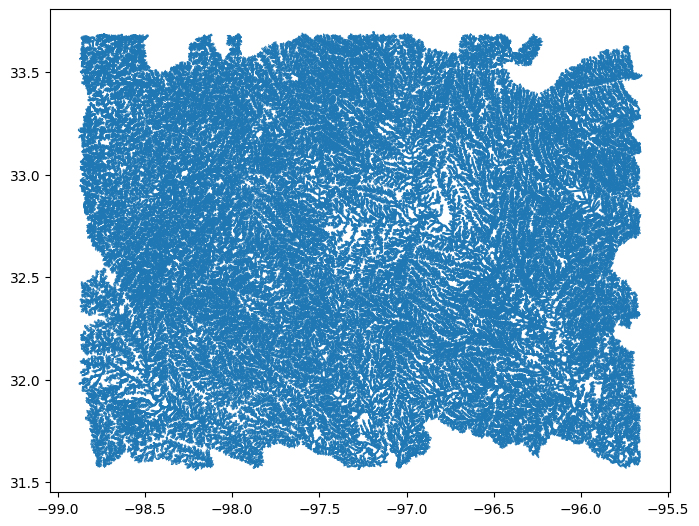

In [19]:
fig, ax = plt.subplots(figsize=(8, 8))
for basin in basins.values():
    basin.plot(ax=ax)

# Create and run Muskingum Models

In [20]:
min_dt = 15.
min_K = min_dt / 2 / (1 - 0.29)

basin_outputs = {}
final_discharges = {}

for watershed_name, basin in basins.items():
    print(watershed_name)
    name = watershed_name
    start_date = pd.to_datetime('2026-01-01T00:00:00', utc=True)
    reach_names = basin['permanent_identifier'].astype(str).values
    reach_ids = basin['id'].astype(str).values
    to_reach_ids = basin['to_id'].fillna(-1).astype(int).astype(str).values
    dx = (basin['lengthkm'] * 1000).values
    K = (dx / 2.12)

    # Establish drainage network topology
    reach_index = pd.Series(basin.index.values, index=reach_ids)
    startnodes = reach_index.reindex(reach_ids, fill_value=-1).values
    endnodes = reach_index.reindex(to_reach_ids, fill_value=-1).values
    self_loops = []
    for i in range(len(startnodes)):
        if endnodes[i] == -1:
            self_loops.append(i)
            endnodes[i] = startnodes[i]

    # Specify parameters
    K = np.maximum(K, 1.5 * min_K)
    X = 0.29 * np.ones(basin.shape[0], dtype=np.float64)                     # Attenuation parameter [-]
    o_t = 0. * np.ones(basin.shape[0], dtype=np.float64)                     # Initial outflow from each reach [m^3/s]

    # Process flowpath geometries
    linestring_geoms = basin.geometry.apply(lambda x: x.geoms[0])            # Note: this flattens multilinestrings
    paths = (linestring_geoms.apply(lambda x: [np.column_stack(x.xy)])
            .values.tolist())

    timedelta = pd.to_timedelta(min_dt, unit='s')
    model_data = {
        'name' : name,
        'datetime' : start_date,
        'timedelta' : timedelta,
        'reach_ids' : reach_names.tolist(),
        'startnodes' : startnodes,
        'endnodes' : endnodes,
        'K' : K,
        'X' : X,
        'o_t' : o_t,
        'dx' : dx,
        'paths' : paths
    }
    model = Muskingum(model_data)
    model.init_states(o_t_next=o_t)
    model.save_state()
    p_t_next = np.ones(model.n)

    outlet_reach = outlets[watershed_name]
    outlet_index = model.reach_ids.index(outlet_reach)
    outputs = {}
    outputs[model.datetime] = model.o_t_next[outlet_index]

    for t in range(4 * 60 * 24 * 7):
        print(t, end='\r')
        model.step(p_t_next)
        outputs[model.datetime] = model.o_t_next[outlet_index]
    ref_outputs = pd.DataFrame.from_dict(outputs, orient='index')
    ref_outputs.columns = [outlet_index]
    ref_outputs.index = pd.to_datetime(ref_outputs.index, utc=True)
    basin_outputs[watershed_name] = ref_outputs
    basin_final_discharges = pd.Series(model.o_t_next.copy(), index=model.reach_ids)
    final_discharges[watershed_name] = basin_final_discharges
    print('\n')


trinity
40319

brazos
40319

tehuacana
40319

north_bosque
40319

leon
40319

cowhouse
40319

pompey
40319

kickapoo
40319

south_sulphur
40319

north_sulphur
40319

white_oak
40319

lake_fork
40319

sabine
40319

choctaw
40319

caney
40319

mill
40319

little_wichita
40319

east_little_wichita
40319

west_belknap
40319

blanket
40319



# Package model instance data into dictionary

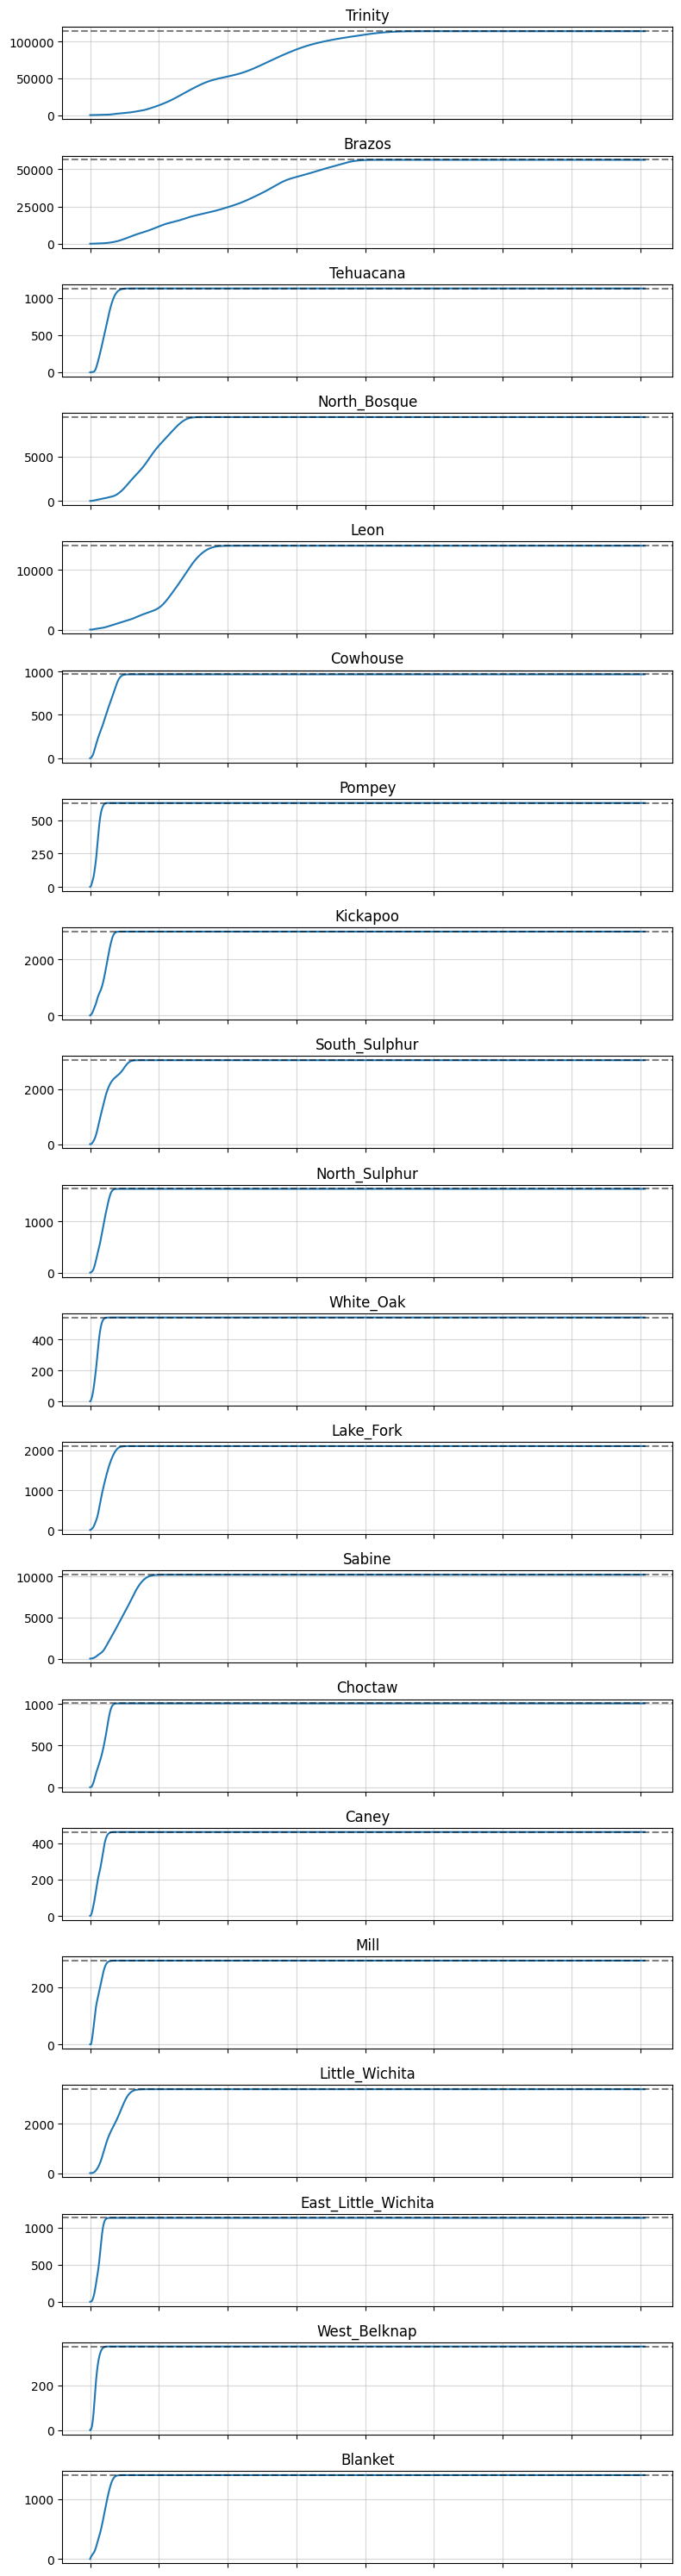

In [21]:
fig, ax = plt.subplots(len(basin_outputs), figsize=(8, 1.5 * len(basin_outputs)))
i = 0
for watershed_name, output in basin_outputs.items():
    num_reaches = len(nhd_flowlines[nhd_flowlines['watershed_name'] == watershed_name])
    ax[i].plot(output.values.ravel())
    ax[i].set_title(watershed_name.title())
    ax[i].axhline(num_reaches, linestyle='--', c='k', alpha=0.5)
    ax[i].grid(alpha=0.5)
    if i <= len(basin_outputs):
        ax[i].xaxis.set_ticklabels([])
    else:
        ax[i].xaxis.set_ticklabels(range(7))
    i += 1

plt.tight_layout()

In [22]:
accumulation_series = pd.concat(final_discharges.values())
nhd_flowlines['accumulation'] = nhd_flowlines['permanent_identifier'].map(accumulation_series).reindex(nhd_flowlines.index).fillna(0.)

Text(0.5, 1.0, 'Accumulation')

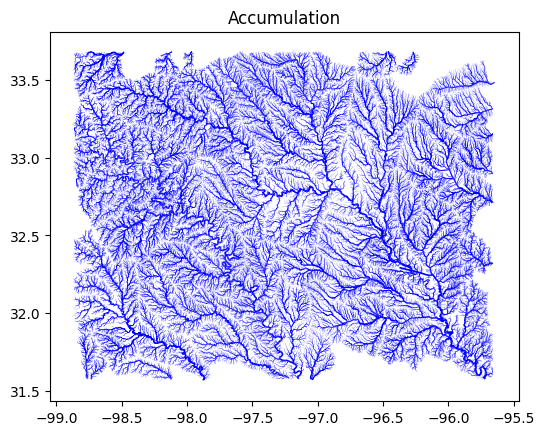

In [23]:
nhd_flowlines.plot(color='b', linewidth=0.25*np.log10(1 + nhd_flowlines['accumulation'].values))
plt.title('Accumulation')

In [24]:
nhd_flowlines.to_file('../data/nhd_flowlines_unidirectional.gpkg')